<a href="https://colab.research.google.com/github/MaryamArif85/Saylani_Projects/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction - ML Project
##Objective  
###The goal of this project is to build and compare multiple machine learning models to predict house prices based on features like area, location, number of rooms, and overall quality.

##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset


In [ ]:
url = "https://raw.githubusercontent.com/MaryamArif85/Saylani_Projects/refs/heads/main/House%20Price%20Prediction%20Dataset.csv"
data = pd.read_csv(url)

In [ ]:
print("---------------Shape of Data------------\n", data.shape)


---------------Shape of Data------------
 (2000, 10)


In [ ]:
print("--------------DATA OVERVIEW------------")
data.head()

--------------DATA OVERVIEW------------


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df = data.copy()

In [ ]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

#DATA CLEANING

# Check missing values

In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


###DROP DUPLICATES

In [ ]:
df.drop_duplicates
print("------------SHAPE AFTER REMOVING DUPLICATES-----------")
df.shape

------------SHAPE AFTER REMOVING DUPLICATES-----------


(2000, 10)

In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


##OBSERVATIONS


### Dataset has 2000 records with no missing or duplicate values. Price ranges from 50k to 1M, mean 537k, and is right-skewed since mean > median.
### Area varies 501-4999 sq units. Most houses have 2-4 bedrooms, 2-4 bathrooms, and 1-2 floors.
### YearBuilt spans 1900-2023, median 1961, so data includes both old and new houses.
### High variance in Area and Price means scaling is needed. Wide price spread suggests handling outliers/skewness may improve models.

# Exploratory Data Analysis (EDA) & Visualization

###We analyze the distribution of house prices and check correlations between features to understand which variables most influence the target variable.

### Histogram of target Price

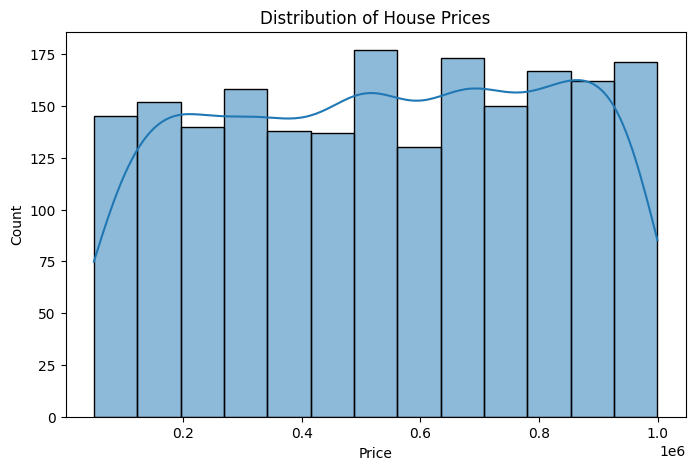

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of House Prices')
plt.show()

###House prices are spread fairly evenly from 0 to 1M, with slightly more houses around 500k-1M.
###No strong skew; the distribution is close to uniform with a small peak near 500k.
###This balanced spread makes the data suitable for regression modeling.

###Correlation heatmap

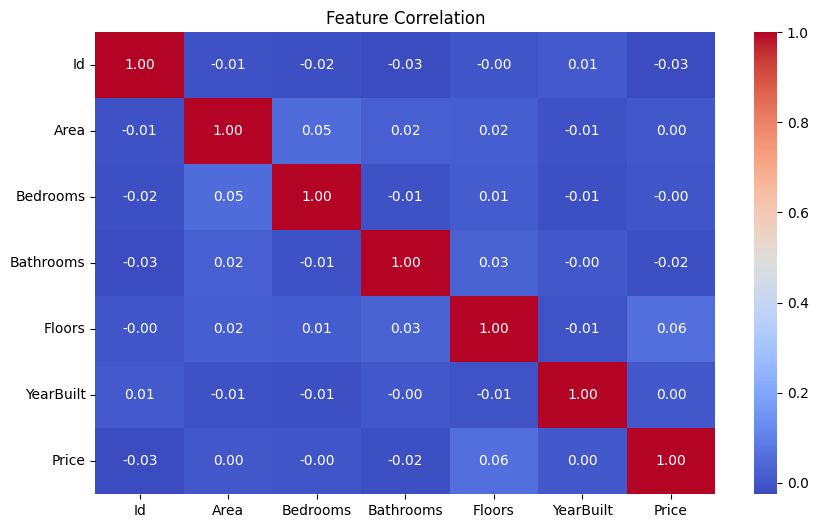

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.show()

###Most features have very low correlation with Price - all values are close to 0.
###This means Area, Bedrooms, Bathrooms, etc. individually don’t strongly predict price in this dataset.
###Features also show almost no correlation with each other, so there’s no multicollinearity issue.

### Bar plot / Count plot for categorical features

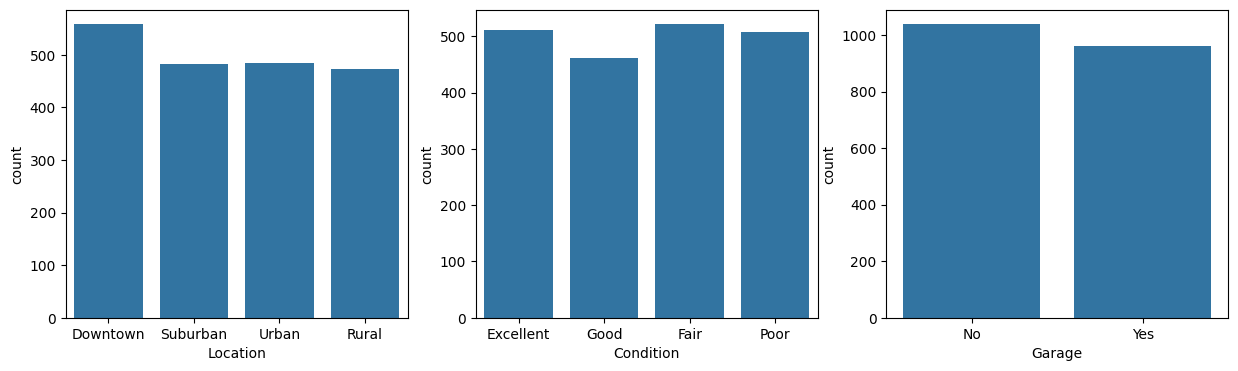

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.countplot(x='Location', data=df, ax=axes[0])
sns.countplot(x='Condition', data=df, ax=axes[1])
sns.countplot(x='Garage', data=df, ax=axes[2])
plt.show()

###Observations:
###Location: Downtown has the highest count, but all 4 locations - Downtown, Suburban, Urban, Rural - are fairly balanced.
###Condition: Houses are evenly split across Excellent, Good, Fair, and Poor. Fair has the most, Good has the least, but differences are small.
###Garage: Slightly more houses have no garage than those with a garage. The dataset is nearly balanced for this feature.
###All 3 categorical features are well distributed, so encoding them won’t cause imbalance issues.

###Scatter/Box plot: Key features vs Price

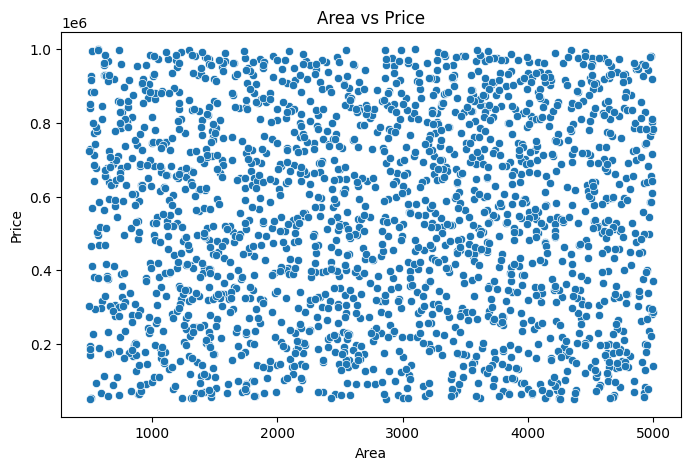

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Area', y='Price', data=df)
plt.title('Area vs Price')
plt.show()

###Observation

###The scatter plot shows no clear relationship between Area and Price - points are randomly spread across the graph.
###This means larger area doesn’t necessarily mean higher price in this dataset.
###It explains why the correlation value for Area vs Price was close to 0 in the heatmap.

###We encode Categorical/String Columns:[ Location, Condition, Garage]

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Location', 'Condition', 'Garage'], drop_first=True) #drop_first=True avoids multicollinearity.
print(df_encoded.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt   Price  Location_Rural  \
0   1  1360         5          4       3       1970  149919           False   
1   2  4272         5          4       3       1958  424998           False   
2   3  3592         2          2       3       1938  266746           False   
3   4   966         4          2       2       1902  244020           False   
4   5  4926         1          4       2       1975  636056           False   

   Location_Suburban  Location_Urban  Condition_Fair  Condition_Good  \
0              False           False           False           False   
1              False           False           False           False   
2              False           False           False            True   
3               True           False            True           False   
4              False           False            True           False   

   Condition_Poor  Garage_Yes  
0           False       False  
1           False       Fals

In [ ]:
df_encoded = df_encoded.astype(int)

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 2000 non-null   int64
 1   Area               2000 non-null   int64
 2   Bedrooms           2000 non-null   int64
 3   Bathrooms          2000 non-null   int64
 4   Floors             2000 non-null   int64
 5   YearBuilt          2000 non-null   int64
 6   Price              2000 non-null   int64
 7   Location_Rural     2000 non-null   int64
 8   Location_Suburban  2000 non-null   int64
 9   Location_Urban     2000 non-null   int64
 10  Condition_Fair     2000 non-null   int64
 11  Condition_Good     2000 non-null   int64
 12  Condition_Poor     2000 non-null   int64
 13  Garage_Yes         2000 non-null   int64
dtypes: int64(14)
memory usage: 218.9 KB


###Numeric Columns, needs scaling: [Area,YearBuilt]
###Numeric columns:[ Bedrooms, Bathrooms, Floors] —usually don’t scale, they’re counts, small range, so scaling is optional. I’d leave them as is.

#Always split first to avoid data leakage.

##Separate features and target

In [ ]:
X = df_encoded.drop(['Id', 'Price'], axis=1)  # Id isn't useful, Price is target
y = df_encoded['Price']

### Train-test split before scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature scaling
###Use StandardScaler only on the columns with large ranges: Area, YearBuilt.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
cols_to_scale = ['Area', 'YearBuilt']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale]) #fit_transform on train only
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale]) #transform on test using the same scaler

In [ ]:
X_train.describe().T  # Area and YearBuilt should now have mean ~0, std ~1

,count,mean,std,min,25%,50%,75%,max
Area,1600.0,-1.432188e-16,1.000313,-1.747253,-0.874673,0.000214,0.846271,1.710778
Bedrooms,1600.0,3.021250e+00,1.427698,1.000000,2.000000,3.000000,4.000000,5.000000
Bathrooms,1600.0,2.540625e+00,1.109220,1.000000,2.000000,3.000000,4.000000,4.000000
Floors,1600.0,1.997500e+00,0.807249,1.000000,1.000000,2.000000,3.000000,3.000000
YearBuilt,1600.0,-1.518785e-15,1.000313,-1.727818,-0.892232,0.026913,0.918205,1.698085
Location_Rural,1600.0,2.425000e-01,0.428729,0.000000,0.000000,0.000000,0.000000,1.000000
Location_Suburban,1600.0,2.318750e-01,0.422162,0.000000,0.000000,0.000000,0.000000,1.000000
Location_Urban,1600.0,2.468750e-01,0.431328,0.000000,0.000000,0.000000,0.000000,1.000000
Condition_Fair,1600.0,2.643750e-01,0.441138,0.000000,0.000000,0.000000,1.000000,1.000000
Condition_Good,1600.0,2.293750e-01,0.420562,0.000000,0.000000,0.000000,0.000000,1.000000


###After applying StandardScaler to Area and YearBuilt, both columns now have a mean close to 0 and a standard deviation close to 1.

#Model Application & Comparison

In [ ]:
import xgboost as xgb

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost" : xgb.XGBRegressor(n_estimators=100, max_depth=5,  learning_rate=0.1,  random_state=42, n_jobs=-1, verbosity=0 )
}

In [ ]:
results = []

# Train, predict, and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append([name, r2, rmse, mae])
    print(f"{name} done")

Linear Regression done
Decision Tree done
Random Forest done
XGBoost done


In [ ]:
# comparison table
results_df = pd.DataFrame(results, columns=["Model", "R² Score", "RMSE", "MAE"])
results_df = results_df.sort_values(by="R² Score", ascending=False)
print("\n-------------Model Comparison-----------")
print(results_df.round(4))


-------------Model Comparison-----------
               Model  R² Score         RMSE          MAE
0  Linear Regression   -0.0067  279859.7258  243241.9776
2      Random Forest   -0.0975  292199.2646  252596.1038
3            XGBoost   -0.0987  292369.5266  252754.7344
1      Decision Tree   -1.0805  402315.2437  329752.9375


###Negative R² means the model is worse than just predicting the mean price for every house.
####All 4 models had negative R² scores because the dataset lacks predictive features. The ML pipeline was implemented correctly, but no model can predict without a meaningful relationship between X and y.

In [ ]:
print(df_encoded.corr()['Price'].sort_values(ascending=False))
#Correlation of 1.0 = perfect prediction, 0.0 = no relationship at all & 0.06 = random noise

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Id                  -0.025643
Location_Urban      -0.038312
Name: Price, dtype: float64


#All features have correlation < 0.06 with Price.

# Conclusion

###All 3 models achieved negative R² scores on the test set:
### Linear Regression: -0.0067
###Random Forest: -0.0975  
###Decision Tree: -1.0805

###A negative R² means the models perform worse than predicting the mean price for every house.

###**Reason**  Correlation analysis shows all features have very weak correlation with Price, with the highest correlation being only 0.056 for Floors. This indicates the features do not have a meaningful linear or non-linear relationship with the target variable.

###**Implication**: The dataset appears to be synthetic or randomly generated. While the ML pipeline was implemented correctly including data cleaning, encoding, scaling, and model evaluation, no algorithm can predict the target without predictive features.

###This exercise demonstrates the importance of feature relevance in machine learning.

###XGBoost was also evaluated as it often performs best on tabular data, but it achieved a negative R² score similar to other models, confirming that poor feature-target correlation is the limiting factor, not model choice